In [2]:
# Переустанавливаем numpy и gensim, чтобы они были совместимы
!pip install --upgrade --force-reinstall numpy gensim
# После этой команды необходимо перезапустить рантайм (Runtime → Restart runtime)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: s

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.1760 - loss: 2.8194 - val_accuracy: 0.0150 - val_loss: 10.4439
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3165 - loss: 2.1138 - val_accuracy: 0.0200 - val_loss: 11.8565
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3444 - loss: 2.0105 - val_accuracy: 0.0147 - val_loss: 14.8461
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3652 - loss: 1.9398 - val_accuracy: 0.0177 - val_loss: 15.8048
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3802 - loss: 1.8879 - val_accuracy: 0.0444 - val_loss: 16.4252
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3962 - loss: 1.8369 - val_accuracy: 0.0397 - val_loss: 18.1000
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4083 - loss: 1.7941 - val_accuracy: 0.0377 - val_loss: 19.5516
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4220 - loss: 1.7558 - val_accu

,Метрика,Значение
0,Точность,0.47
1,Precision (macro),0.38
2,Recall (macro),0.43
3,F1-score (macro),0.38


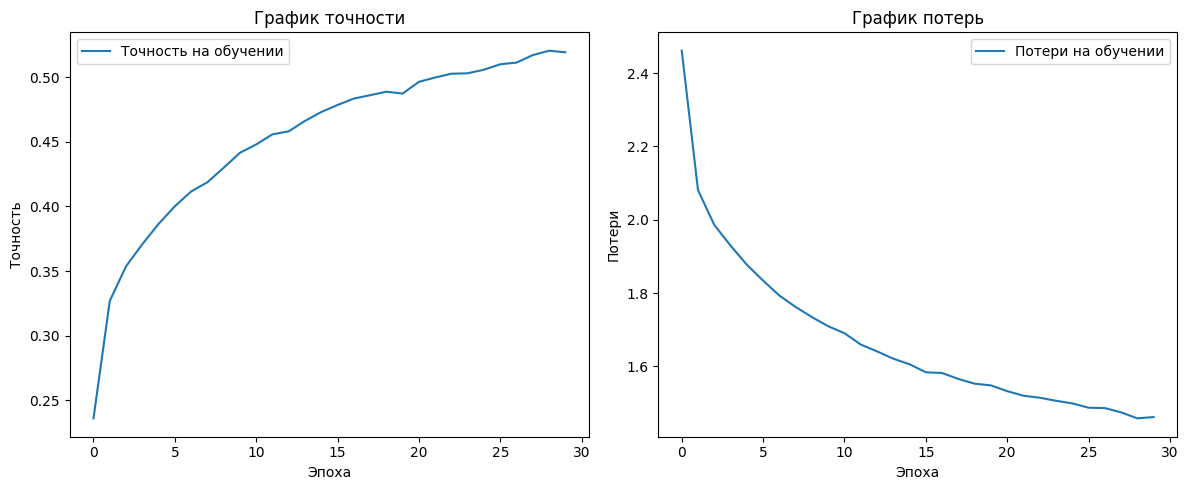

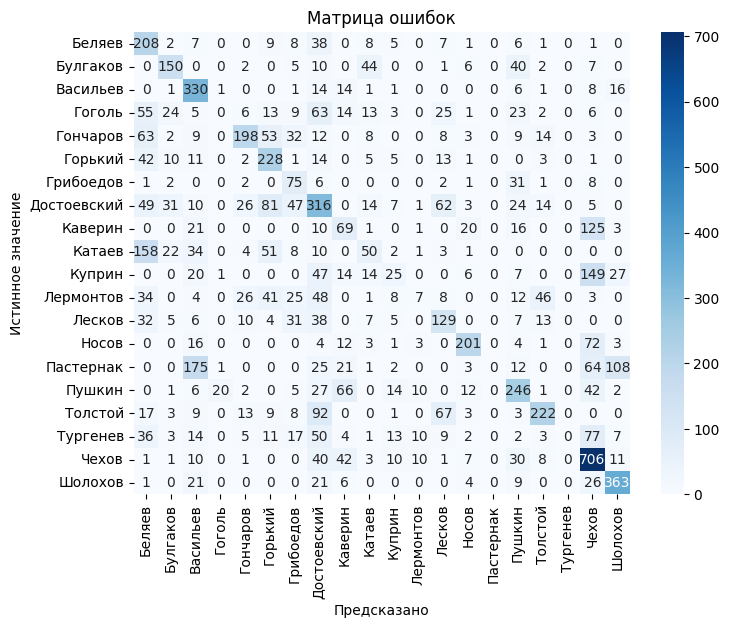

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import string
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from google.colab import drive
from nltk.corpus import stopwords
import nltk

# Настройка matplotlib для кириллицы
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# Загружаем стоп-слова для русского языка
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

# Функция для удаления стоп-слов и пунктуации
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])  # Удаляем пунктуацию
    text = ' '.join([word for word in text.split() if word not in stop_words])  # Удаляем стоп-слова
    return text

def read_full_texts(folder_path, prefix='train_'):
    texts, labels = [], []
    for fn in os.listdir(folder_path):
        if fn.startswith(prefix) and fn.endswith('.txt'):
            author = fn[len(prefix):].replace('.txt','')
            path = os.path.join(folder_path, fn)
            try:
                with open(path, 'r', encoding='utf-8') as f:
                    texts.append(f.read())
            except UnicodeDecodeError:
                with open(path, 'r', encoding='cp1251') as f:
                    texts.append(f.read())
            labels.append(author)
    return texts, labels

def split_into_fixed_fragments(texts, labels, fragment_len=1500, min_len=1000):
    frags, frag_labels = [], []
    for txt, lab in zip(texts, labels):
        for i in range(0, len(txt), fragment_len):
            frag = txt[i:i+fragment_len]
            if len(frag) >= min_len:
                frags.append(frag)
                frag_labels.append(lab)
    return frags, frag_labels

def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.title('График точности'); plt.xlabel('Эпоха'); plt.ylabel('Точность'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на обучении')
    plt.title('График потерь'); plt.xlabel('Эпоха'); plt.ylabel('Потери'); plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Предсказано'); plt.ylabel('Истинное значение')
    plt.title('Матрица ошибок')
    plt.show()

def print_key_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    df = pd.DataFrame({
        'Метрика': ['Точность', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)'],
        'Значение': [f"{acc:.2f}", f"{precision:.2f}", f"{recall:.2f}", f"{f1:.2f}"]
    })
    display(df)

if __name__ == '__main__':
    drive.mount('/content/drive')

    base = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Выборка'
    # 1) Считываем тексты
    train_texts_full, train_labels_full = read_full_texts(os.path.join(base, 'Train'), 'train_')
    test_texts_full, test_labels_full = read_full_texts(os.path.join(base, 'Test'), 'test_')

    # 2) Фрагментация
    train_texts, train_labels = split_into_fixed_fragments(train_texts_full, train_labels_full)
    test_texts, test_labels = split_into_fixed_fragments(test_texts_full, test_labels_full)

    # 3) Предобработка: удаляем стоп-слова и пунктуацию
    train_texts = [preprocess_text(txt) for txt in train_texts]
    test_texts = [preprocess_text(txt) for txt in test_texts]

    # 4) Подготовка токенов для Word2Vec
    corpus = [txt.split() for txt in train_texts]

    # 5) Обучаем Word2Vec на корпусе
    embed_dim = 100
    w2v = Word2Vec(sentences=corpus, vector_size=embed_dim, window=5, min_count=1, workers=4)

    # 6) Токенизация и преобразование текстов в последовательности индексов
    max_words = 5000
    max_len = 500

    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_texts)

    X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=max_len, padding='post')
    X_test = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=max_len, padding='post')

    # 7) Создаём матрицу эмбеддингов
    word_index = tokenizer.word_index
    embedding_matrix = np.zeros((max_words, embed_dim))
    for word, i in word_index.items():
        if i >= max_words:
            continue
        if word in w2v.wv:
            embedding_matrix[i] = w2v.wv[word]

    # 8) Кодируем метки
    le = LabelEncoder()
    y_train = to_categorical(le.fit_transform(train_labels))
    y_test = to_categorical(le.transform(test_labels))

    # 9) Модель Word2Vec + Conv1D
    from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

    model = Sequential([
        Embedding(input_dim=max_words,
                  output_dim=embed_dim,
                  input_length=max_len,
                  weights=[embedding_matrix],
                  trainable=False),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 10) Обучение
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

    # 11) Оценка
    y_pred = np.argmax(model.predict(X_test, batch_size=32), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print_key_metrics(y_true, y_pred)
    plot_metrics(history)
    plot_confusion_matrix(y_true, y_pred, le.classes_)
